# CS4305 Artificial Intelligence — Lab 9
## Knowledge Representation II: Rules (Production Systems)

**What you will learn today**
1. Write knowledge as **IF-THEN rules**
2. Build a **forward-chaining** engine (facts → conclusions)
3. Build a **backward-chaining** engine (goal → facts)
4. Make the system **ask questions** like a real expert system
5. Compare **conflict resolution** strategies

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _text_tree(ax, children, root, labels, colors=None, gap=1.6, w=1.35, h=0.5, fs=12, level_gap=1.1):
    """Draw a tree whose nodes are text boxes. labels: node-id -> text."""
    colors = colors or {}
    pos = tree_layout(children, root, gap=gap)
    pos = {k: (x, y * level_gap) for k, (x, y) in pos.items()}
    for p, ks in children.items():
        for k in ks:
            (x1, y1), (x2, y2) = pos[p], pos[k]
            ax.plot([x1, x2], [y1 - h / 2, y2 + h / 2], color=GREY, lw=1.8, zorder=1)
    for k, (x, y) in pos.items():
        fc = colors.get(k, PURPLE)
        box(ax, x - w / 2, y - h / 2, w, h, labels.get(k, k), fc=fc, tc=DARK if fc in (ORANGE, LIGHT, WHITE) else WHITE, fs=fs)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - w, max(xs) + w); ax.set_ylim(min(ys) - h * 1.5, max(ys) + h * 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    return pos

ZOO = [("R1", ["has_hair"], "mammal"), ("R2", ["gives_milk"], "mammal"), ("R3", ["has_feathers"], "bird"),
       ("R4", ["mammal", "eats_meat"], "carnivore"), ("R5", ["carnivore", "tawny", "dark_spots"], "cheetah"),
       ("R6", ["carnivore", "tawny", "black_stripes"], "tiger"), ("R7", ["bird", "swims", "cannot_fly"], "penguin")]

NET_POS = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
           "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
           "milk": (7.4, 0.8), "yellow": (-1.4, 0.2)}

NET_EDGES = [("Bird", "Animal", "is-a"), ("Mammal", "Animal", "is-a"), ("Canary", "Bird", "is-a"), ("Penguin", "Bird", "is-a"),
             ("Cow", "Mammal", "is-a"), ("Tweety", "Canary", "instance"), ("Bird", "fly", "can"), ("Bird", "feathers", "has"),
             ("Animal", "breathe", "can"), ("Cow", "milk", "gives"), ("Canary", "yellow", "colour")]

def _net(ax, path=None, exception=True):
    concept = {"Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"}
    on = set(zip(path, path[1:])) if path else set()
    for a, b, lab in NET_EDGES:
        (x1, y1), (x2, y2) = NET_POS[a], NET_POS[b]
        hi = (a, b) in on
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=4 if hi else 1.8,
                    color=ORANGE if hi else GREY, shrinkA=22, shrinkB=22, mutation_scale=16))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=10.5, ha="center", va="center", color=DARK,
                bbox=dict(boxstyle="round,pad=0.15", fc=WHITE, ec="none"))
    if exception:
        (x1, y1), (x2, y2) = NET_POS["Penguin"], NET_POS["fly"]
        ax.annotate("", xy=(x2 + 0.3, y2 - 0.2), xytext=(x1 - 0.3, y1 + 0.1), arrowprops=dict(arrowstyle="-|>", lw=2, color=ROSE, ls="--",
                    connectionstyle="arc3,rad=-0.25", shrinkA=14, shrinkB=14))
        ax.text(0.2, 1.55, "can: NO", fontsize=10.5, color=ROSE, fontweight="bold")
    for n_, (x, y) in NET_POS.items():
        if n_ in concept:
            c = ORANGE if n_ == "Tweety" else PURPLE
            box(ax, x - 0.62, y - 0.28, 1.24, 0.56, n_, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        else:
            box(ax, x - 0.55, y - 0.25, 1.1, 0.5, n_, fc=LIGHT, tc=DARK, fs=11, bold=False)
    ax.set_xlim(-2.1, 8.1); ax.set_ylim(-1.3, 4.9); ax.set_aspect("equal"); ax.axis("off")
print('Diagram tools ready')

---
## Part 1: A production system
A rule-based (production) system has three parts: a **rule base**, a **working memory** of facts, and an **inference engine** that repeats *match → resolve → act*.

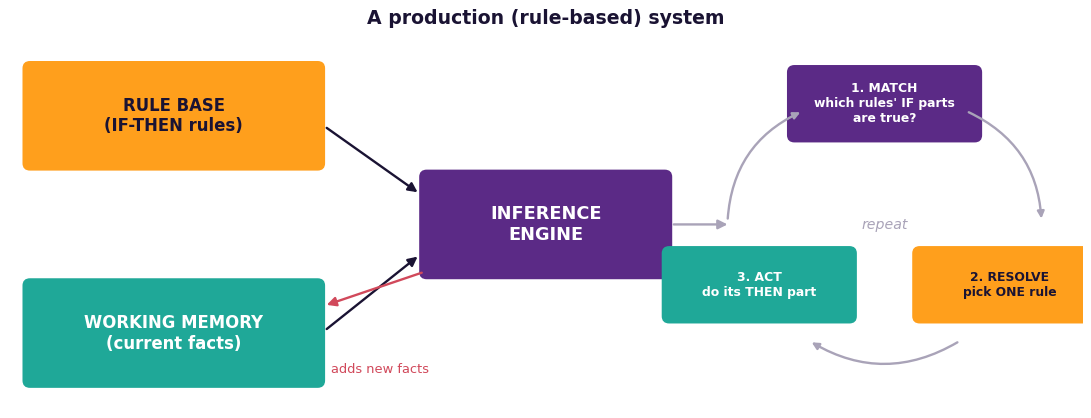

In [ ]:
#@title 📊 Visual explanation: the parts of a production system
def fig_production_system():
    fig, ax = plt.subplots(figsize=(13, 5))
    box(ax, 0.2, 3.1, 3.6, 1.3, "RULE BASE\n(IF-THEN rules)", fc=ORANGE, tc=DARK, fs=14)
    box(ax, 0.2, 0.4, 3.6, 1.3, "WORKING MEMORY\n(current facts)", fc=TEAL, fs=14)
    box(ax, 5.0, 1.75, 3.0, 1.3, "INFERENCE\nENGINE", fc=PURPLE, fs=15)
    arrow(ax, 3.85, 3.6, 4.95, 2.8); arrow(ax, 3.85, 1.1, 4.95, 2.0); arrow(ax, 5.0, 1.8, 3.85, 1.4, color=ROSE)
    ax.text(3.9, 0.55, "adds new facts", fontsize=11, color=ROSE)
    cx, cy = 10.6, 2.4
    for i, (t, c) in enumerate([("1. MATCH\nwhich rules' IF parts\nare true?", PURPLE), ("2. RESOLVE\npick ONE rule", ORANGE), ("3. ACT\ndo its THEN part", TEAL)]):
        ang = np.pi / 2 - i * 2 * np.pi / 3
        x, y = cx + 1.75 * np.cos(ang), cy + 1.5 * np.sin(ang)
        box(ax, x - 1.15, y - 0.45, 2.3, 0.9, t, fc=c, tc=DARK if c == ORANGE else WHITE, fs=10.5)
    for i in range(3):
        a1, a2 = np.pi / 2 - i * 2 * np.pi / 3 - 0.55, np.pi / 2 - (i + 1) * 2 * np.pi / 3 + 0.55
        ax.annotate("", xy=(cx + 1.9 * np.cos(a2), cy + 1.65 * np.sin(a2)), xytext=(cx + 1.9 * np.cos(a1), cy + 1.65 * np.sin(a1)),
                    arrowprops=dict(arrowstyle="-|>", color=GREY, lw=2, connectionstyle="arc3,rad=-0.3"))
    ax.text(cx, cy, "repeat", ha="center", va="center", fontsize=12, color=GREY, style="italic")
    arrow(ax, 8.05, 2.4, 8.7, 2.4, color=GREY)
    ax.set_xlim(0, 13); ax.set_ylim(0.1, 4.6); ax.axis("off")
    finish(fig, "A production (rule-based) system")
    return fig

fig_production_system()
plt.show()

In [ ]:
# ===== The knowledge base: IF-THEN rules about animals =====
rules = [
    ("R1",  ["has_hair"],                               "mammal"),
    ("R2",  ["gives_milk"],                             "mammal"),
    ("R3",  ["has_feathers"],                           "bird"),
    ("R4",  ["flies", "lays_eggs"],                     "bird"),
    ("R5",  ["mammal", "eats_meat"],                    "carnivore"),
    ("R6",  ["mammal", "has_claws", "pointed_teeth"],   "carnivore"),
    ("R7",  ["carnivore", "tawny", "dark_spots"],       "cheetah"),
    ("R8",  ["carnivore", "tawny", "black_stripes"],    "tiger"),
    ("R9",  ["mammal", "has_hooves", "long_neck"],      "giraffe"),
    ("R10", ["bird", "cannot_fly", "swims"],            "penguin"),
    ("R11", ["bird", "flies_well"],                     "eagle"),
]
for name, conds, concl in rules:
    print(f"{name:4s}: IF {' AND '.join(conds):38s} THEN {concl}")

---
## Part 2: Forward chaining (data-driven)
Start with the **facts you know**, fire every rule whose IF-part is true, add the new facts, and repeat until nothing new can be found.

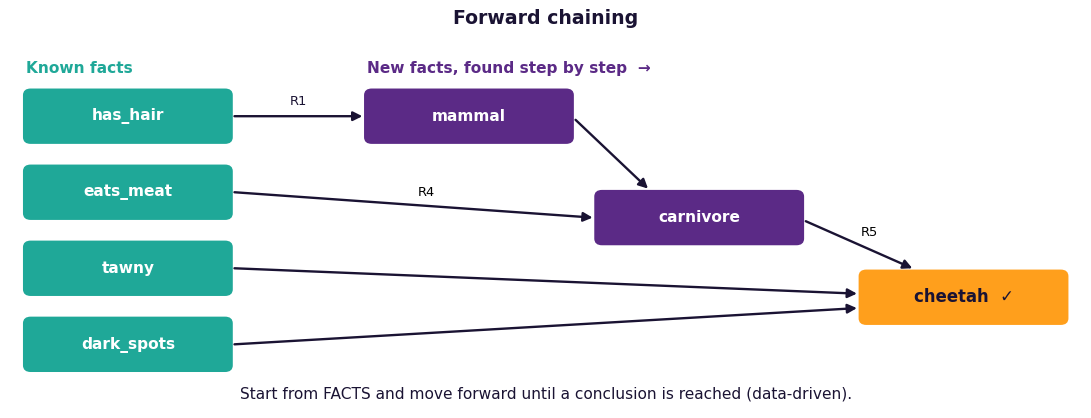

In [ ]:
#@title 📊 Visual explanation: from facts to 'cheetah'
def fig_forward_chain():
    fig, ax = plt.subplots(figsize=(13, 5))
    facts = ["has_hair", "eats_meat", "tawny", "dark_spots"]
    for i, f in enumerate(facts):
        box(ax, 0.2, 3.6 - i * 1.05, 2.4, 0.7, f, fc=TEAL, fs=13)
    box(ax, 4.2, 3.6, 2.4, 0.7, "mammal", fc=PURPLE, fs=13); box(ax, 6.9, 2.2, 2.4, 0.7, "carnivore", fc=PURPLE, fs=13)
    box(ax, 10.0, 1.1, 2.4, 0.7, "cheetah  ✓", fc=ORANGE, tc=DARK, fs=14)
    arrow(ax, 2.65, 3.95, 4.15, 3.95, text="R1"); arrow(ax, 6.65, 3.9, 7.5, 2.95, text="")
    arrow(ax, 2.65, 2.9, 6.85, 2.55); ax.text(4.8, 2.85, "R4", fontsize=11)
    arrow(ax, 9.35, 2.5, 10.6, 1.85); ax.text(10.0, 2.3, "R5", fontsize=11)
    arrow(ax, 2.65, 1.85, 9.95, 1.5); arrow(ax, 2.65, 0.8, 9.95, 1.3)
    ax.text(0.2, 4.55, "Known facts", fontsize=13, color=TEAL, fontweight="bold")
    ax.text(4.2, 4.55, "New facts, found step by step  →", fontsize=13, color=PURPLE, fontweight="bold")
    ax.text(6.3, 0.05, "Start from FACTS and move forward until a conclusion is reached (data-driven).", ha="center", fontsize=13, color=DARK)
    ax.set_xlim(0, 12.6); ax.set_ylim(-0.1, 4.9); ax.axis("off")
    finish(fig, "Forward chaining")
    return fig

fig_forward_chain()
plt.show()

In [ ]:
# ===== Forward chaining: the MATCH → RESOLVE → ACT cycle =====
def forward_chain(facts, rules, verbose=True):
    memory = set(facts)                 # working memory
    fired = set()
    cycle = 0
    while True:
        cycle += 1
        # 1. MATCH: rules whose IF-parts are all in memory (and not fired before)
        conflict_set = [r for r in rules if r[0] not in fired and all(c in memory for c in r[1])]
        if not conflict_set:
            if verbose: print(f"Cycle {cycle}: no rule can fire. STOP.")
            return memory
        # 2. RESOLVE: here we simply take the FIRST matching rule
        name, conds, concl = conflict_set[0]
        # 3. ACT: add the conclusion to working memory
        memory.add(concl); fired.add(name)
        if verbose:
            print(f"Cycle {cycle}: conflict set = {[r[0] for r in conflict_set]}  →  fire {name}  →  add '{concl}'")

facts = ["has_hair", "eats_meat", "tawny", "dark_spots"]
print("Starting facts:", facts, "\n")
result = forward_chain(facts, rules)
print("\nFinal working memory:", sorted(result))

In [ ]:
# ===== Try another animal =====
result = forward_chain(["has_feathers", "cannot_fly", "swims"], rules)
print("Conclusions:", sorted(result - {"has_feathers", "cannot_fly", "swims"}))

---
## Part 3: Backward chaining (goal-driven)
Start with a **question** ("Is it a cheetah?"). Find a rule that concludes it, and try to prove each of its conditions — which may need other rules. Prolog works this way.

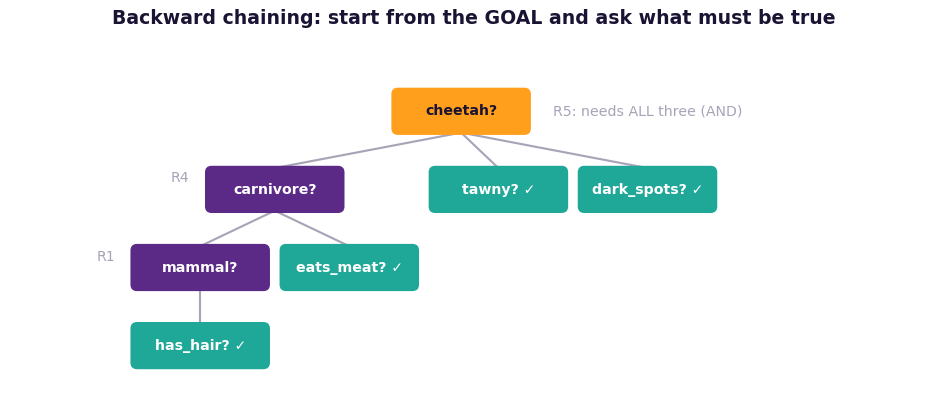

In [ ]:
#@title 📊 Visual explanation: proving 'cheetah' backwards
def fig_backward_tree():
    children = {"g": ["c", "t", "d"], "c": ["m", "e"], "m": ["h"]}
    labels = {"g": "cheetah?", "c": "carnivore?", "t": "tawny? ✓", "d": "dark_spots? ✓", "m": "mammal?", "e": "eats_meat? ✓", "h": "has_hair? ✓"}
    colors = {"g": ORANGE, "c": PURPLE, "m": PURPLE, "t": TEAL, "d": TEAL, "e": TEAL, "h": TEAL}
    fig, ax = plt.subplots(figsize=(12, 5))
    pos = _text_tree(ax, children, "g", labels, colors, gap=2.1, w=1.9, h=0.6, fs=12)
    ax.text(pos["g"][0] + 1.3, pos["g"][1], "R5: needs ALL three (AND)", fontsize=12, color=GREY, va="center")
    ax.text(pos["c"][0] - 1.2, pos["c"][1] + 0.1, "R4", fontsize=12, color=GREY, ha="right")
    ax.text(pos["m"][0] - 1.2, pos["m"][1] + 0.1, "R1", fontsize=12, color=GREY, ha="right")
    ax.set_xlim(ax.get_xlim()[0] - 0.8, ax.get_xlim()[1] + 2.2)
    finish(fig, "Backward chaining: start from the GOAL and ask what must be true")
    return fig

fig_backward_tree()
plt.show()

In [ ]:
# ===== Backward chaining: start from the GOAL =====
def backward_chain(goal, facts, rules, depth=0):
    pad = "    " * depth
    if goal in facts:
        print(f"{pad}✓ {goal} is a known fact")
        return True
    for name, conds, concl in rules:
        if concl == goal:
            print(f"{pad}? to prove {goal}, try {name}: needs {conds}")
            if all(backward_chain(c, facts, rules, depth + 1) for c in conds):
                print(f"{pad}✓ {goal} proved by {name}")
                return True
    print(f"{pad}✗ cannot prove {goal}")
    return False

facts = {"has_hair", "eats_meat", "tawny", "dark_spots"}
print("Is it a cheetah?\n")
print("\nAnswer:", backward_chain("cheetah", facts, rules))

In [ ]:
print("Is it a tiger?\n")
print("\nAnswer:", backward_chain("tiger", facts, rules))

### Asking the user
A real expert system does not know all facts in advance — it **asks** only the questions it needs. Here we give the answers in advance (demo). Call `identify()` to answer yourself.

In [ ]:
# ===== Backward chaining that ASKS questions (like a real expert system) =====
askable = {"has_hair", "gives_milk", "has_feathers", "flies", "lays_eggs", "eats_meat", "has_claws", "pointed_teeth",
           "tawny", "dark_spots", "black_stripes", "has_hooves", "long_neck", "cannot_fly", "swims", "flies_well"}

def make_asker(answers=None):
    known = {}
    def ask(fact):
        if fact not in known:
            if answers is not None:                         # demo mode: answers given in advance
                reply = answers.get(fact, "no")
                print(f"   Q: Does the animal have/do '{fact}'? → {reply}")
            else:                                           # interactive mode: you type the answer
                reply = input(f"   Q: Does the animal have/do '{fact}'? (yes/no) ").strip().lower()
            known[fact] = reply.startswith("y")
        return known[fact]
    return ask

def prove(goal, ask):
    if goal in askable:
        return ask(goal)
    return any(all(prove(c, ask) for c in conds) for name, conds, concl in rules if concl == goal)

def identify(answers=None):
    ask = make_asker(answers)
    for animal in ["cheetah", "tiger", "giraffe", "penguin", "eagle"]:
        print(f"Trying hypothesis: {animal}")
        if prove(animal, ask):
            return animal
    return "unknown animal"

# Demo with answers given in advance (a giraffe):
print("Result:", identify({"has_hair": "yes", "has_hooves": "yes", "long_neck": "yes"}))
# To answer yourself, run:  identify()

---
## Part 4: Conflict resolution
Sometimes **several rules match** at the same time (the *conflict set*). The engine needs a strategy to choose which rule fires first.

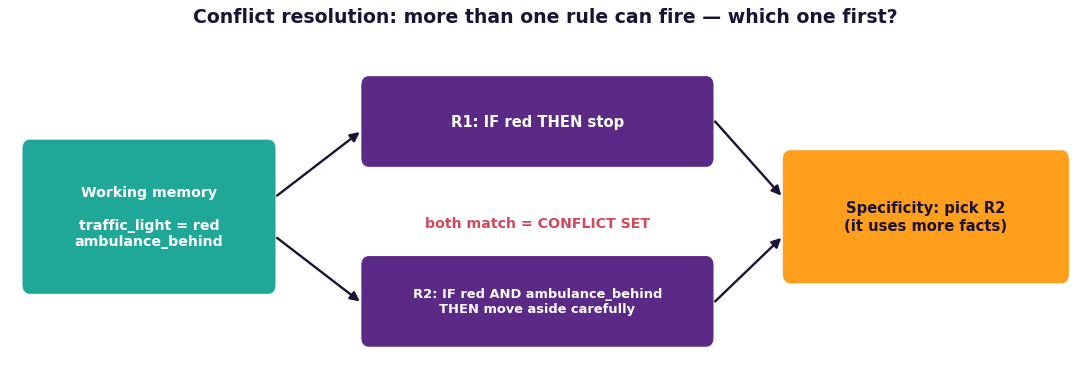

In [ ]:
#@title 📊 Visual explanation: two rules match — which one wins?
def fig_conflict():
    fig, ax = plt.subplots(figsize=(13, 4.6))
    box(ax, 0.2, 1.6, 3.0, 1.4, "Working memory\n\ntraffic_light = red\nambulance_behind", fc=TEAL, fs=12)
    box(ax, 4.3, 2.8, 4.2, 0.8, "R1: IF red THEN stop", fc=PURPLE, fs=12.5)
    box(ax, 4.3, 1.1, 4.2, 0.8, "R2: IF red AND ambulance_behind\nTHEN move aside carefully", fc=PURPLE, fs=11)
    arrow(ax, 3.25, 2.5, 4.25, 3.1); arrow(ax, 3.25, 2.1, 4.25, 1.5)
    ax.text(6.4, 2.2, "both match = CONFLICT SET", ha="center", fontsize=12, color=ROSE, fontweight="bold")
    box(ax, 9.4, 1.7, 3.4, 1.2, "Specificity: pick R2\n(it uses more facts)", fc=ORANGE, tc=DARK, fs=12.5)
    arrow(ax, 8.55, 1.5, 9.35, 2.1); arrow(ax, 8.55, 3.2, 9.35, 2.5)
    ax.set_xlim(0, 13); ax.set_ylim(0.8, 3.9); ax.axis("off")
    finish(fig, "Conflict resolution: more than one rule can fire — which one first?")
    return fig

fig_conflict()
plt.show()

In [ ]:
# ===== Conflict resolution strategies =====
wm = {"light_red", "ambulance_behind"}
traffic_rules = [
    {"name": "R1", "if": {"light_red"}, "then": "stop", "priority": 1, "added": 1},
    {"name": "R2", "if": {"light_red", "ambulance_behind"}, "then": "move_aside_carefully", "priority": 5, "added": 3},
    {"name": "R3", "if": {"light_green"}, "then": "go", "priority": 1, "added": 2},
]
conflict_set = [r for r in traffic_rules if r["if"] <= wm]
print("Conflict set:", [r["name"] for r in conflict_set])

strategies = {
    "First rule in the list":           lambda cs: cs[0],
    "Specificity (most conditions)":    lambda cs: max(cs, key=lambda r: len(r["if"])),
    "Priority / salience (highest)":    lambda cs: max(cs, key=lambda r: r["priority"]),
    "Recency (newest rule)":            lambda cs: max(cs, key=lambda r: r["added"]),
}
for name, pick in strategies.items():
    r = pick(conflict_set)
    print(f"{name:32s} → fire {r['name']}: {r['then']}")

---
## Part 5: Forward or backward?
Forward chaining finds **everything** that follows from the facts. Backward chaining only looks at what is needed for **one goal**.

In [ ]:
# ===== Which direction does less work? =====
import io, contextlib
# many facts in memory at once (e.g. a zoo database)
facts = ["has_hair", "eats_meat", "tawny", "dark_spots", "has_hooves", "long_neck", "has_feathers", "flies_well"]
with contextlib.redirect_stdout(io.StringIO()):
    fc = forward_chain(facts, rules)
print("Forward chaining derived:", sorted(fc - set(facts)), " (everything it could!)")
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    backward_chain("cheetah", set(facts), rules)
print("Backward chaining for 'cheetah' checked only", len(buf.getvalue().splitlines()), "steps, all about cheetahs.")

---
## 📝 Lab Tasks
1. Add rules for **zebra** (mammal AND has_hooves AND black_stripes) and **ostrich**. Test them with forward chaining.
2. Change the resolve step in `forward_chain` so it picks the rule with the **most conditions** (specificity).
3. Run `identify()` and answer the questions for a **tiger**.
4. Write 6 rules for a **university advisor**: e.g. IF cgpa_below_2 THEN probation; IF probation AND failed_course THEN repeat_course …
5. **Think:** a doctor has many symptoms and wants to know *what disease* it could be. Would you use forward or backward chaining? Why?